# Proyecto ciencia de datos (metodologia CRISP-DM)

## Fases CRISP-DM 
- 1) Comprensión del negocio (documentar objetivo/problema).
- 2) Comprensión de los datos (carga unificada + EDA inicial).
- 3) Preparación de los datos (siguientes pasos).
- 4) Modelado 
- 5) Evaluación (pendiente).
- 6) Despliegue (no requerido)

## 1. Business Understanding 

### Preguntas de negocio:
- ¿Qué características hacen que un juego supere los 10M en ventas?
- ¿Las secuelas venden más?
- ¿Importa más la plataforma o el género? 

### Stakeholders: publishers, desarrolladores, inversores, plataformas

### Criterios de éxito: 
    R² > 0.65 en test, MAE < 0.5 en log-ventas

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import  MLPRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingRegressor

sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

ModuleNotFoundError: No module named 'scipy'

In [ ]:
# Ruta del dataset
DATA_DIR = Path("./datasets")
csv_files = sorted(DATA_DIR.glob("*.csv"))

print(f"CSV encontrados: {len(csv_files)}")
for f in csv_files:
    print("-", f.name)

CSV encontrados: 5
- games.csv
- genre_summary.csv
- platform_summary.csv
- publisher_summary.csv
- yearly_trends.csv


In [ ]:
def read_csv_flexible(file_path: Path) -> pd.DataFrame:
    #manejo de csv"
    separators = [",", ";", "\t", "|"]
    for sep in separators:
        try:
            df = pd.read_csv(file_path, sep=sep, engine="python")
            if df.shape[1] > 1:
                return df
        except Exception:
            continue
    return pd.read_csv(file_path)

# raw_tables -> tablas og
raw_tables = {}
print(csv_files[0])
raw_tables["games"] = read_csv_flexible(csv_files[0])
print(raw_tables.keys())

df_all = raw_tables["games"].copy()

for file_path in csv_files:
    table_name = file_path.stem
    df_temp = read_csv_flexible(file_path)
    raw_tables[table_name] = df_temp.copy()

print(f"Df originales: {list(raw_tables.keys())}")

# mergear en tabla principal: games (con game_id)
df_all = raw_tables["games"].copy()

if "genre_summary" in raw_tables:
    genre_cols = raw_tables["genre_summary"].columns.tolist()
    genre_cols = [f"genre_{col}" if col != "genre" else col for col in genre_cols]
    df_genre = raw_tables["genre_summary"].copy()
    df_genre.columns = genre_cols
    df_all = df_all.merge(df_genre, on="genre", how="left")
    print(f"✓ Merged genre_summary: +{len(genre_cols)-1} columnas")

# Merge con platform_summary por plataforma
if "platform_summary" in raw_tables:
    platform_cols = raw_tables["platform_summary"].columns.tolist()
    platform_cols = [f"platform_{col}" if col != "platform" else col for col in platform_cols]
    df_platform = raw_tables["platform_summary"].copy()
    df_platform.columns = platform_cols
    df_all = df_all.merge(df_platform, on="platform", how="left")
    print(f"✓ Merged platform_summary: +{len(platform_cols)-1} columnas")

# Merge con publisher_summary por publicador
if "publisher_summary" in raw_tables:
    pub_cols = raw_tables["publisher_summary"].columns.tolist()
    pub_cols = [f"pub_{col}" if col != "publisher" else col for col in pub_cols]
    df_pub = raw_tables["publisher_summary"].copy()
    df_pub.columns = pub_cols
    df_all = df_all.merge(df_pub, on="publisher", how="left")
    print(f"✓ Merged publisher_summary: +{len(pub_cols)-1} columnas")

# Merge con yearly_trends por año
if "yearly_trends" in raw_tables:
    year_cols = raw_tables["yearly_trends"].columns.tolist()
    year_cols = [f"year_{col}" if col != "year" else col for col in year_cols]
    df_year = raw_tables["yearly_trends"].copy()
    df_year.columns = year_cols
    df_all = df_all.merge(df_year, on="year", how="left")
    print(f"✓ Merged yearly_trends: +{len(year_cols)-1} columnas")

datasets/games.csv
dict_keys(['games'])
Df originales: ['games', 'genre_summary', 'platform_summary', 'publisher_summary', 'yearly_trends']
✓ Merged genre_summary: +10 columnas
✓ Merged platform_summary: +8 columnas
✓ Merged publisher_summary: +8 columnas
✓ Merged yearly_trends: +10 columnas


In [ ]:

print(f"Forma: {df_all.shape}")
print(f"Número de columnas: {len(df_all.columns)}")
print(f"\nPrimeras filas:")
display(df_all.head())

print(f"\nMuestra aleatoria:")
display(df_all.sample(min(5, len(df_all)), random_state=42))

Forma: (50000, 71)
Número de columnas: 71

Primeras filas:


,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,publisher_region,publisher_tier,esrb_rating,metacritic_score,user_score,critic_review_count,user_review_count,na_sales_million,eu_sales_million,jp_sales_million,other_sales_million,global_sales_million,estimated_revenue_million_usd,launch_price_usd,is_sequel,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs,genre_titles,genre_total_sales_m,genre_avg_sales_m,genre_avg_metacritic,genre_avg_user_score,genre_pct_goty_nominated,genre_avg_htlb_main,genre_pct_online,genre_pct_dlc,genre_pct_microtransactions,platform_platform_type,platform_platform_maker,platform_titles,platform_total_sales_m,platform_avg_metacritic,platform_avg_user_score,platform_top_genre,platform_avg_launch_price,pub_publisher_tier,pub_publisher_region,pub_titles,pub_total_sales_m,pub_avg_metacritic,pub_goty_wins,pub_avg_revenue_m,pub_pct_sequels,year_titles_released,year_total_sales_m,year_avg_metacritic,year_avg_user_score,year_pct_online,year_pct_microtransactions,year_pct_dlc,year_avg_launch_price,year_goty_games,year_avg_htlb
0,G000001,eFootball 2023,Game Boy,Handheld,Nintendo,4,Sports,1990,CD Projekt,Deep Silver,Poland,AAA,M,69,6.7,34,1172,10.01,8.35,2.58,3.46,24.40,575.88,49.99,1,1,1,0,0,0,0,0,0,31.8,86.1,5571,263838.83,47.36,71.24,7.14,0.02,20.02,1.00,0.62,0.49,Handheld,Nintendo,2107,26967.00,74.20,7.40,Action,34.79,AAA,Poland,1417,46506.04,75.99,8,819.63,0.40,820,17152.72,75.507,7.534,0.511,0.251,0.687,52.313,2,24.967
1,G000002,Doom 3,Xbox,Console,Microsoft,6,Rhythm,2004,Ubisoft,Ubisoft,France,AAA,M,78,9.4,5,186,52.28,33.72,5.32,12.30,103.62,5056.51,59.99,1,0,1,1,0,0,0,0,0,13.1,55.4,460,6783.49,14.75,73.63,7.34,0.04,12.03,0.28,0.60,0.25,Console,Microsoft,991,23441.55,73.35,7.35,Action,59.45,AAA,France,1440,45677.74,75.54,5,803.36,0.41,1178,23133.98,73.337,7.333,0.491,0.260,0.680,42.237,10,26.334
2,G000003,God of Fire,PC,PC,Various,0,Misc,1988,Microsoft Studios,Microsoft Studios,USA,AAA,T,76,6.6,33,363,2.90,1.48,0.75,0.91,6.04,138.60,59.99,0,0,0,0,0,0,0,0,0,9.8,20.9,1896,25942.19,13.68,69.22,6.91,0.01,11.98,0.30,0.62,0.27,PC,Various,6305,116852.54,74.17,7.42,Action,32.62,AAA,USA,1411,44643.65,75.67,20,781.40,0.41,814,17387.19,75.371,7.560,0.495,0.247,0.643,52.588,14,24.863
3,G000004,Call of Duty: Rising Sun,Mobile (Android),Mobile,Google,0,Shooter,2017,InXile Entertainment,InXile Entertainment,USA,AA,M,62,7.0,28,532,6.76,3.27,0.73,2.34,13.10,36.98,0.00,0,1,1,1,0,0,0,0,0,9.1,44.8,4741,169891.12,35.83,74.04,7.41,0.04,8.00,1.00,0.63,0.50,Mobile,Google,2483,177063.57,74.33,7.45,Action,2.27,AA,USA,691,5562.13,68.33,1,195.64,0.41,1412,46612.49,73.892,7.373,0.506,0.445,0.604,35.959,10,24.553
4,G000005,Fortnite 3,Nintendo 64,Console,Nintendo,5,Battle Royale,1999,Naughty Dog,id Software,USA,AAA,AO,62,5.6,58,1280,25.12,15.94,7.02,7.71,55.79,2148.24,69.99,1,1,0,1,0,0,0,0,0,150.8,322.3,949,37460.91,39.47,74.16,7.45,0.04,100.73,1.00,0.60,0.50,Console,Nintendo,878,16735.18,73.35,7.32,Action,60.63,AAA,USA,1468,45628.52,75.46,15,774.38,0.41,1225,21266.58,73.457,7.378,0.520,0.253,0.656,49.084,8,24.738



Muestra aleatoria:


,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,publisher_region,publisher_tier,esrb_rating,metacritic_score,user_score,critic_review_count,user_review_count,na_sales_million,eu_sales_million,jp_sales_million,other_sales_million,global_sales_million,estimated_revenue_million_usd,launch_price_usd,is_sequel,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs,genre_titles,genre_total_sales_m,genre_avg_sales_m,genre_avg_metacritic,genre_avg_user_score,genre_pct_goty_nominated,genre_avg_htlb_main,genre_pct_online,genre_pct_dlc,genre_pct_microtransactions,platform_platform_type,platform_platform_maker,platform_titles,platform_total_sales_m,platform_avg_metacritic,platform_avg_user_score,platform_top_genre,platform_avg_launch_price,pub_publisher_tier,pub_publisher_region,pub_titles,pub_total_sales_m,pub_avg_metacritic,pub_goty_wins,pub_avg_revenue_m,pub_pct_sequels,year_titles_released,year_total_sales_m,year_avg_metacritic,year_avg_user_score,year_pct_online,year_pct_microtransactions,year_pct_dlc,year_avg_launch_price,year_goty_games,year_avg_htlb
33553,G033554,NBA 2025,Mobile (iOS),Mobile,Apple,0,Sports,2014,Sony Interactive,Sony Interactive,Japan,AAA,M,75,7.6,25,253,219.48,99.39,153.00,65.67,537.54,1203.16,0.99,1,1,1,0,0,0,0,0,0,11.9,53.2,5571,263838.83,47.36,71.24,7.14,0.02,20.02,1.00,0.62,0.49,Mobile,Apple,2622,178785.27,74.18,7.38,Action,2.23,AAA,Japan,1552,57556.85,75.28,8,947.03,0.41,1368,34372.29,74.275,7.397,0.517,0.258,0.567,37.240,10,24.651
9427,G009428,Wipeout 3,Sega Saturn,Console,Sega,5,Racing,1994,Square Enix,Square Enix,Japan,AAA,T,85,8.1,42,160,9.83,7.20,5.98,1.59,24.60,746.41,69.99,1,0,1,0,0,0,0,0,0,14.0,58.4,3371,82745.33,24.55,74.40,7.43,0.05,15.09,0.29,0.64,0.25,Console,Sega,724,14022.96,73.85,7.40,Action,60.28,AAA,Japan,1468,56513.43,75.35,17,963.02,0.40,838,16919.36,75.579,7.550,0.499,0.251,0.696,52.037,5,26.925
199,G000200,Tales of World,NES,Console,Nintendo,3,Role-Playing,1985,Ubisoft,Toby Fox,France,AAA,T,76,6.8,63,149,1.40,0.90,0.32,0.42,3.04,108.27,39.99,0,1,0,0,0,0,0,0,0,66.2,152.1,4267,108963.88,25.54,77.46,7.76,0.09,54.96,0.29,0.62,0.24,Console,Nintendo,3045,66603.19,74.30,7.42,Action,60.14,AAA,France,1440,45677.74,75.54,5,803.36,0.41,847,18106.27,74.934,7.495,0.511,0.248,0.699,50.273,6,24.156
12447,G012448,God of Steel,PlayStation 5,Console,Sony,9,Misc,2020,InXile Entertainment,InXile Entertainment,USA,AA,E,72,7.3,23,247,1.54,0.76,0.41,0.50,3.21,119.93,69.99,0,1,1,1,0,0,0,0,0,21.1,90.0,1896,25942.19,13.68,69.22,6.91,0.01,11.98,0.30,0.62,0.27,Console,Sony,1223,37457.27,74.19,7.42,Action,59.83,AA,USA,691,5562.13,68.33,1,195.64,0.41,1415,49368.41,74.261,7.409,0.506,0.415,0.586,32.857,12,25.092
39489,G039490,Oxenfree Remastered,PlayStation 5,Console,Sony,9,Adventure,2022,Sega,Sega,Japan,AAA,T,80,8.3,50,380,13.67,8.59,5.29,1.38,28.93,960.10,49.99,0,1,1,0,0,0,0,0,0,6.6,17.6,2397,39900.59,16.65,76.59,7.66,0.07,11.83,0.33,0.61,0.24,Console,Sony,1223,37457.27,74.19,7.42,Action,59.83,AAA,Japan,1560,59199.69,75.78,16,949.42,0.42,1335,47045.16,74.065,7.440,0.500,0.423,0.585,35.107,5,25.658


In [ ]:
# Resumen rápido de estructura y calidad de datos
quality_summary = pd.DataFrame({
    "dtype": df_all.dtypes.astype(str),
    "missing_count": df_all.isna().sum(),
    "missing_pct": (df_all.isna().mean() * 100).round(2),
    "n_unique": df_all.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

display(quality_summary.head(30))

,dtype,missing_count,missing_pct,n_unique
game_id,object,0,0.0,50000
title,object,0,0.0,1391
platform,object,0,0.0,33
platform_type,object,0,0.0,7
platform_maker,object,0,0.0,8
platform_generation,int64,0,0.0,10
genre,object,0,0.0,20
year,int64,0,0.0,42
publisher,object,0,0.0,51
developer,object,0,0.0,51


Dimensiones de cada tabla cargada:
  games                → (50000, 35)
  genre_summary        → (20, 11)
  platform_summary     → (33, 9)
  publisher_summary    → (51, 9)
  yearly_trends        → (42, 11)
Registros por tabla: {'games': 50000, 'genre_summary': 20, 'platform_summary': 33, 'publisher_summary': 51, 'yearly_trends': 42}


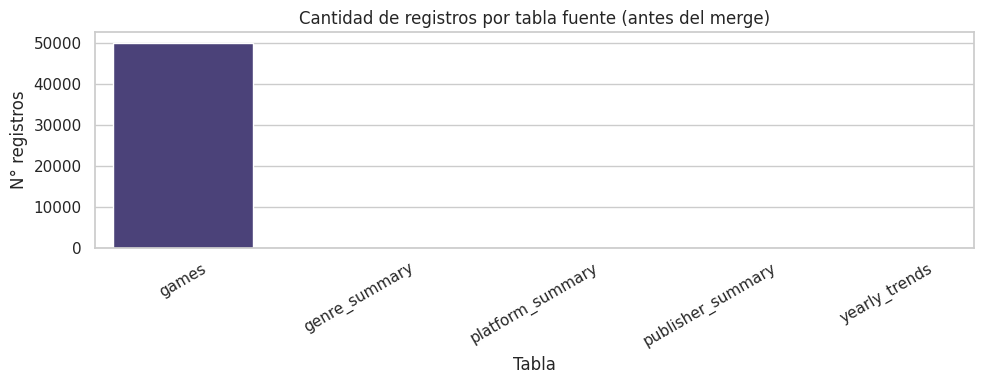

In [ ]:
# Visualización 1: cobertura de datos por tabla origen
print("Dimensiones de cada tabla cargada:")
for table_name, df_table in raw_tables.items():
    print(f"  {table_name:20} → {df_table.shape}")

plt.figure(figsize=(10, 4))
table_names = list(raw_tables.keys())
row_counts = [raw_tables[t].shape[0] for t in table_names]
print(f"Registros por tabla: {dict(zip(table_names, row_counts))}")
sns.barplot(x=table_names, y=row_counts, hue=table_names, palette="viridis", legend=False)
plt.title("Cantidad de registros por tabla fuente (antes del merge)")
plt.xlabel("Tabla")
plt.ylabel("N° registros")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

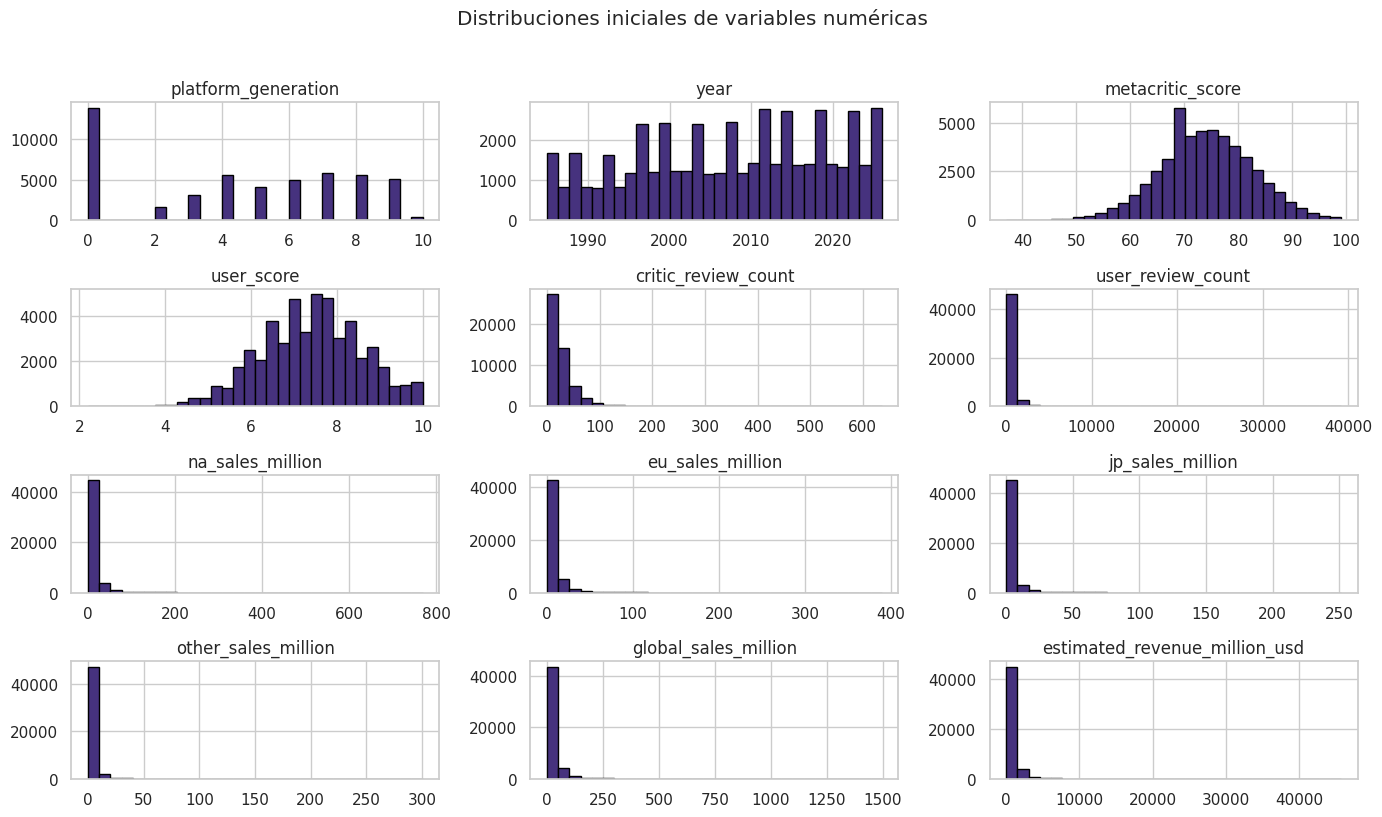

In [ ]:
# Visualización 2: distribución de variables numéricas (primeras 8)
numeric_cols = df_all.select_dtypes(include="number").columns.tolist()
plot_cols = numeric_cols[:12]

if len(plot_cols) > 0:
    df_all[plot_cols].hist(figsize=(14, 8), bins=30, edgecolor="black")
    plt.suptitle("Distribuciones iniciales de variables numéricas", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No se detectaron columnas numéricas para histogramas.")

Total columnas numéricas: 55
Primeras numéricas: ['platform_generation', 'year', 'metacritic_score', 'user_score', 'critic_review_count', 'user_review_count', 'na_sales_million', 'eu_sales_million', 'jp_sales_million', 'other_sales_million', 'global_sales_million', 'estimated_revenue_million_usd', 'launch_price_usd', 'is_sequel', 'online_multiplayer']


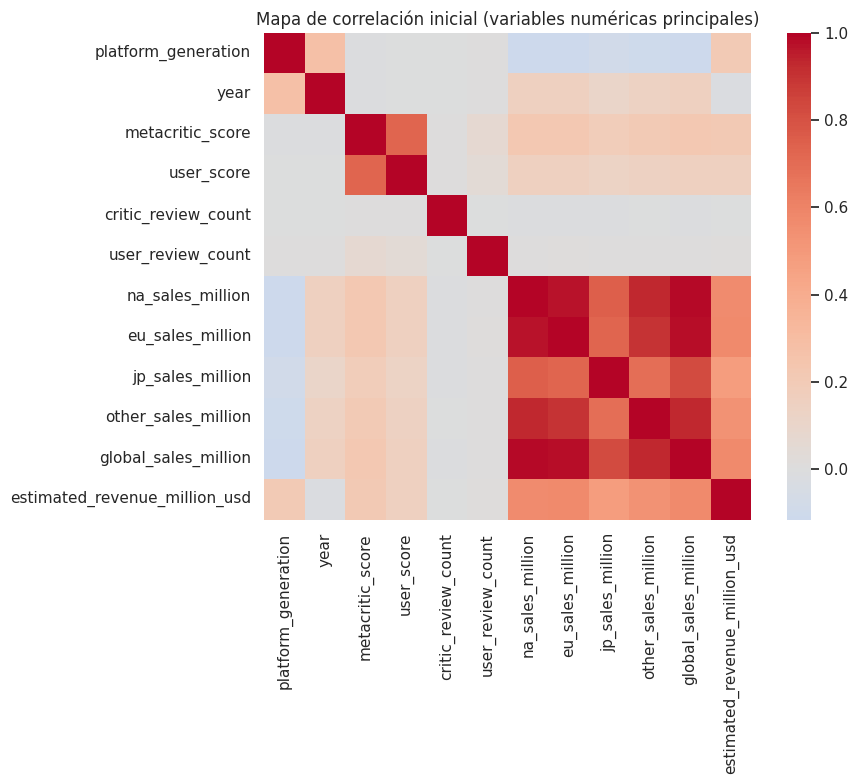

In [ ]:
# Visualización 3: matriz de correlación de variables numéricas principales (subset)
numeric_cols = df_all.select_dtypes(include="number").columns.tolist()
print(f"Total columnas numéricas: {len(numeric_cols)}")
print(f"Primeras numéricas: {numeric_cols[:15]}")

# Seleccionar subset para visualizar
corr_cols = numeric_cols[:12]  # Primeras 12 columnas numéricas

if len(corr_cols) >= 2:
    corr_matrix = df_all[corr_cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, square=True)
    plt.title("Mapa de correlación inicial (variables numéricas principales)")
    plt.tight_layout()
    plt.show()
else:
    print("No hay suficientes columnas numéricas válidas para correlación.")

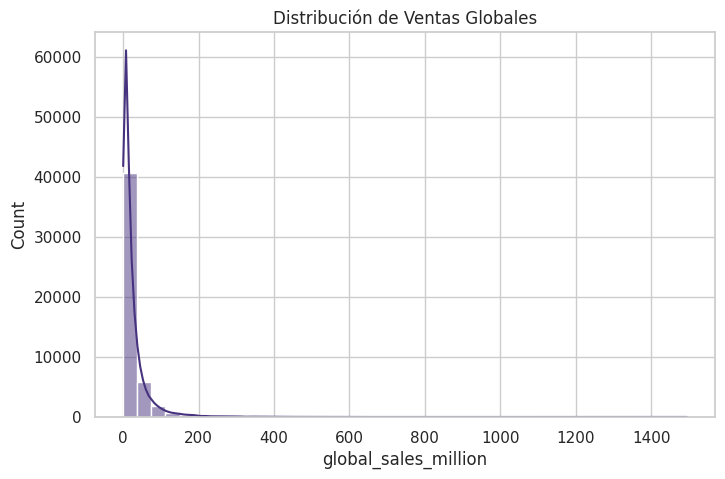

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_all["global_sales_million"], bins=40, kde=True)
plt.title("Distribución de Ventas Globales")
plt.show()

# YA QUE VAMOS A PREDECIR SALES_GLOBAL_MILLION VAMOS A ANALIZAR Y ORGANIZAR LOS DATOS PARA ELLO

In [ ]:
# Asimetria (skewness) de ventas globales

print(
    "Skewness:",
    df_all["global_sales_million"].skew()
)

Skewness: 7.528597362272897


### Ya que la asimetria es bastante superior a 2 vamos a aplicar una transformación logaritmica a nuestra variable para reducir la cola que presenta

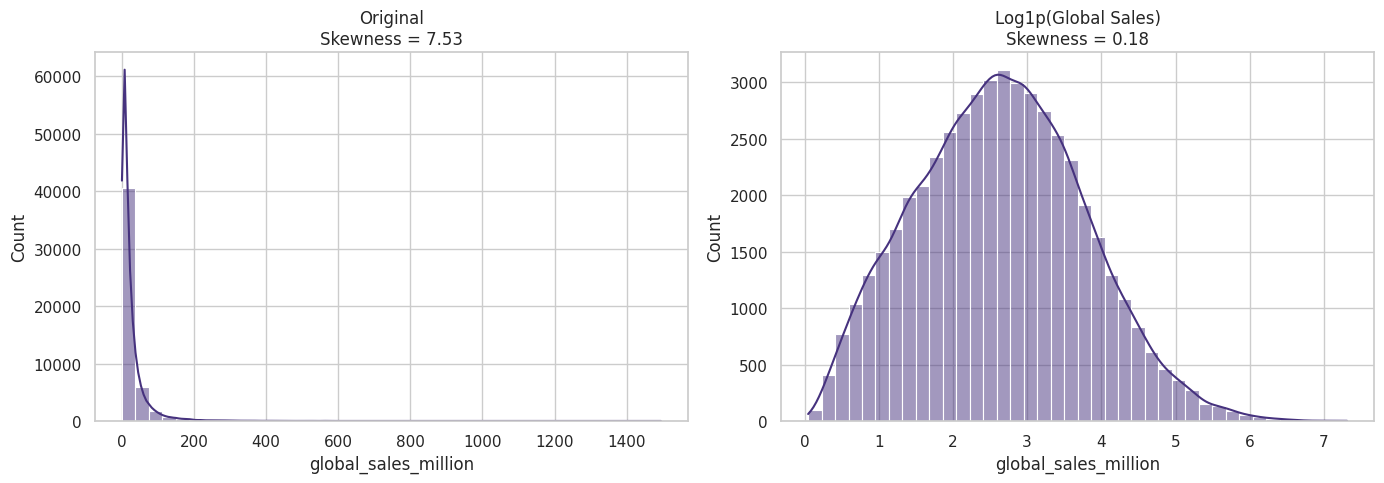

In [ ]:
sales_original = df_all["global_sales_million"]

# Transformación logarítmica
sales_log = np.log1p(sales_original)

# Skewness
skew_original = sales_original.skew()
skew_log = sales_log.skew()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(
    sales_original,
    bins=40,
    kde=True,
    ax=axes[0]
)

axes[0].set_title(
    f"Original\nSkewness = {skew_original:.2f}"
)

sns.histplot(
    sales_log,
    bins=40,
    kde=True,
    ax=axes[1]
)

axes[1].set_title(
    f"Log1p(Global Sales)\nSkewness = {skew_log:.2f}"
)

plt.tight_layout()
plt.show()

## Para evitar Data Leakage eliminamos todas las columnas derivadas de las ventas

In [ ]:
# Columnas con fuga de información (data leakage)

columns_to_drop = [
    "na_sales_million",
    "eu_sales_million",
    "jp_sales_million",
    "other_sales_million",
    "genre_total_sales_m",
    "genre_avg_sales_m",
    "platform_total_sales_m",
    "pub_total_sales_m",
    "pub_avg_revenue_m"
    "year_total_sales_m",
    "estimated_revenue_million_usd"
]

df_all = df_all.drop(columns=columns_to_drop)

print(f"Nueva dimensión: {df_all.shape}")
print("\nColumnas eliminadas correctamente.")

Nueva dimensión: (50000, 61)

Columnas eliminadas correctamente.


### Tambien eliminaremos columnas que no aportan información util

In [ ]:
columns_to_drop = [
    "game_id"
    "genre_titles"
]

df_all = df_all.drop(columns=columns_to_drop)

NameError: name 'df_all' is not defined

## Importante tener en cuenta que columans como "title, "developer" o "publisher" se mantendran para identificarlas en el analisis pero no serán usadas en los modelos ya que generaran ruido

# Preparación de los datos

In [ ]:
# Verificación de nulos y duplicados

# Cantidad de nulos por columna
null_counts = df_all.isnull().sum()
# Mostrar solo columnas con nulos
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
print(f"Columnas con valores nulos: {len(null_counts)}")
display(null_counts)

duplicates = df_all.duplicated().sum()

print(f"Registros duplicados: {duplicates}")

Columnas con valores nulos: 0


Series([], dtype: int64)

Registros duplicados: 0


ANÁLISIS DE OUTLIERS (Z-SCORE > 3)
  metacritic_score                         →     86 outliers (0.17%)
  user_score                               →     88 outliers (0.18%)
  critic_review_count                      →    917 outliers (1.83%)
  user_review_count                        →    757 outliers (1.51%)
  global_sales_million                     →    875 outliers (1.75%)
  loot_boxes                               →   3251 outliers (6.50%)
  game_pass_available                      →   1826 outliers (3.65%)
  vr_support                               →   1221 outliers (2.44%)
  goty_nominated                           →   2232 outliers (4.46%)
  goty_won                                 →    338 outliers (0.68%)
  how_long_to_beat_main_hrs                →   1320 outliers (2.64%)
  how_long_to_beat_completionist_hrs       →   1218 outliers (2.44%)
  genre_avg_htlb_main                      →   1413 outliers (2.83%)
  genre_pct_dlc                            →    956 outliers (1.91%)

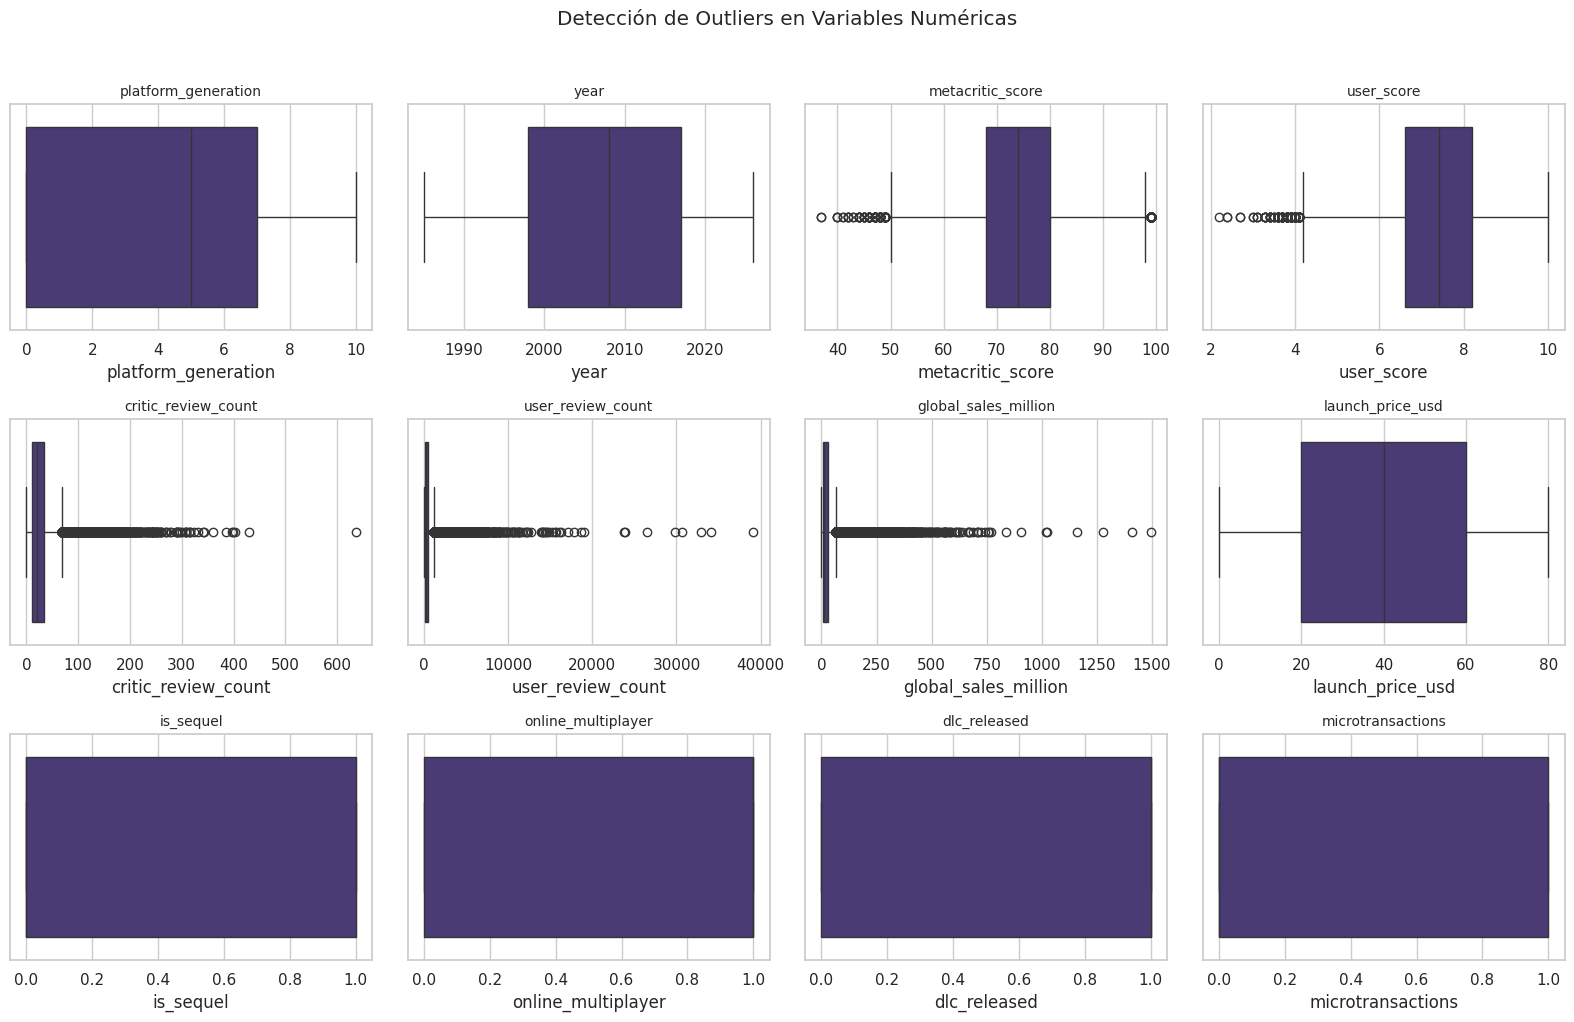

In [ ]:
# Análisis de outliers en variables numéricas
from scipy import stats

numeric_outlier_cols = df_all.select_dtypes(include='number').columns.tolist()

# Z-score para detectar outliers (|z| > 3)
z_scores = np.abs(stats.zscore(df_all[numeric_outlier_cols].dropna()))
outlier_mask = (z_scores > 3)

print("="*60)
print("ANÁLISIS DE OUTLIERS (Z-SCORE > 3)")
print("="*60)
for i, col in enumerate(numeric_outlier_cols):
    n_outliers = outlier_mask[:, i].sum()
    pct = 100 * n_outliers / len(df_all)
    if n_outliers > 0:
        print(f"  {col:40s} → {n_outliers:6d} outliers ({pct:.2f}%)")

# Boxplot de las principales variables numéricas
plot_cols = [c for c in numeric_outlier_cols if c in df_all.columns][:12]
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    sns.boxplot(x=df_all[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Detección de Outliers en Variables Numéricas", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Rescalar metacritic_score de 0-100 a 0-10 para mejor comparabilidad
if 'metacritic_score' in df_all.columns:
    df_all['metacritic_score'] = df_all['metacritic_score'] / 10
    print("✓ metacritic_score rescalada de 0-100 a 0-10")
'''


if 'user_score' in df_all.columns:
    df_all['user_score'] = df_all['user_score'] / 10
    print("✓ user_score rescalada de 0-10 a 0-10")
'''    
#el conteo de reviews puee ser leakage
if 'critic_review_count' in df_all.columns:
    df_all.drop(columns=['critic_review_count'], inplace=True)
if 'user_review_count' in df_all.columns:
    df_all.drop(columns=['user_review_count'], inplace=True)    
if 'goty_won' in df_all.columns:
    df_all.drop(columns=['goty_won'], inplace=True)
if 'goty_nominated' in df_all.columns:
    df_all.drop(columns=['goty_nominated'], inplace=True)
if 'genre_pct_goty_nominated' in df_all.columns:
    df_all.drop(columns=['genre_pct_goty_nominated'], inplace=True)
if 'pub_goty_wins' in df_all.columns:
    df_all.drop(columns=['pub_goty_wins'], inplace=True)
if 'year_goty_games' in df_all.columns:
    df_all.drop(columns=['year_goty_games'], inplace=True)

# idea cambiar categoorizacion ara evitar cola en feature generation
if 'platform_type' in df_all.columns and 'platform_generation' in df_all.columns:
    mobile_mask = df_all['platform_type'] == 'Mobile'
    if mobile_mask.any():
        df_all.loc[mobile_mask, 'platform_generation'] = df_all['platform_generation'].max() + 1
        print(f"✓ Asignado platform_generation {df_all['platform_generation'].max()} a filas Mobile")
    else:
        print("⚠️ No hay filas con platform_type == 'Mobile' para ajustar")


''' 
Q1 = df_all['metacritic_score'].quantile(0.25)
Q3 = df_all['metacritic_score'].quantile(0.75)
IQR = Q3 - Q1
df_all = df_all[(df_all['metacritic_score'] >= Q1 - 1.5*IQR) & 
                 (df_all['metacritic_score'] <= Q3 + 1.5*IQR)]

Q1 = df_all['user_score'].quantile(0.25)
Q3 = df_all['user_score'].quantile(0.75)
IQR = Q3 - Q1
df_all = df_all[(df_all['user_score'] >= Q1 - 1.5*IQR) & 
                 (df_all['user_score'] <= Q3 + 1.5*IQR)]
'''



✓ metacritic_score rescalada de 0-100 a 0-10
✓ Asignado platform_generation 11 a filas Mobile


" \nQ1 = df_all['metacritic_score'].quantile(0.25)\nQ3 = df_all['metacritic_score'].quantile(0.75)\nIQR = Q3 - Q1\ndf_all = df_all[(df_all['metacritic_score'] >= Q1 - 1.5*IQR) & \n                 (df_all['metacritic_score'] <= Q3 + 1.5*IQR)]\n\nQ1 = df_all['user_score'].quantile(0.25)\nQ3 = df_all['user_score'].quantile(0.75)\nIQR = Q3 - Q1\ndf_all = df_all[(df_all['user_score'] >= Q1 - 1.5*IQR) & \n                 (df_all['user_score'] <= Q3 + 1.5*IQR)]\n"

<Axes: xlabel='platform_generation', ylabel='Count'>

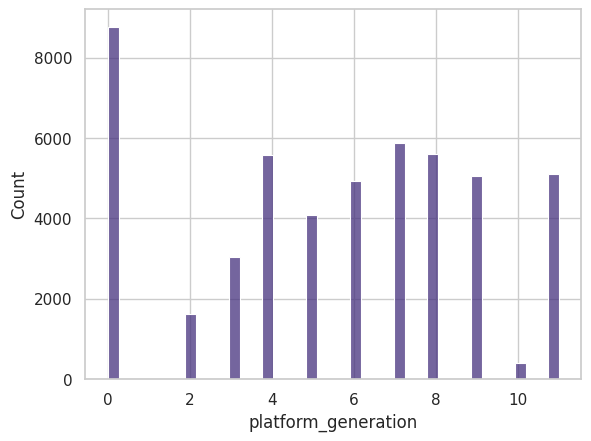

In [ ]:
sns.histplot(x=df_all['platform_generation'])

creamos una nueva categoria para redcir la cola en este feature y asi tener un parametro de encoding adicional posteriormente

In [ ]:
df_all.head()

,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,publisher_region,publisher_tier,esrb_rating,metacritic_score,user_score,global_sales_million,launch_price_usd,is_sequel,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs,genre_titles,genre_avg_metacritic,genre_avg_user_score,genre_pct_goty_nominated,genre_avg_htlb_main,genre_pct_online,genre_pct_dlc,genre_pct_microtransactions,platform_platform_type,platform_platform_maker,platform_titles,platform_avg_metacritic,platform_avg_user_score,platform_top_genre,platform_avg_launch_price,pub_publisher_tier,pub_publisher_region,pub_titles,pub_avg_metacritic,pub_goty_wins,pub_avg_revenue_m,pub_pct_sequels,year_titles_released,year_avg_metacritic,year_avg_user_score,year_pct_online,year_pct_microtransactions,year_pct_dlc,year_avg_launch_price,year_goty_games,year_avg_htlb
0,eFootball 2023,Game Boy,Handheld,Nintendo,4,Sports,1990,CD Projekt,Deep Silver,Poland,AAA,M,6.9,6.7,24.40,49.99,1,1,1,0,0,0,0,0,31.8,86.1,5571,71.24,7.14,0.02,20.02,1.00,0.62,0.49,Handheld,Nintendo,2107,74.20,7.40,Action,34.79,AAA,Poland,1417,75.99,8,819.63,0.40,820,75.507,7.534,0.511,0.251,0.687,52.313,2,24.967
1,Doom 3,Xbox,Console,Microsoft,6,Rhythm,2004,Ubisoft,Ubisoft,France,AAA,M,7.8,9.4,103.62,59.99,1,0,1,1,0,0,0,0,13.1,55.4,460,73.63,7.34,0.04,12.03,0.28,0.60,0.25,Console,Microsoft,991,73.35,7.35,Action,59.45,AAA,France,1440,75.54,5,803.36,0.41,1178,73.337,7.333,0.491,0.260,0.680,42.237,10,26.334
2,God of Fire,PC,PC,Various,0,Misc,1988,Microsoft Studios,Microsoft Studios,USA,AAA,T,7.6,6.6,6.04,59.99,0,0,0,0,0,0,0,0,9.8,20.9,1896,69.22,6.91,0.01,11.98,0.30,0.62,0.27,PC,Various,6305,74.17,7.42,Action,32.62,AAA,USA,1411,75.67,20,781.40,0.41,814,75.371,7.560,0.495,0.247,0.643,52.588,14,24.863
3,Call of Duty: Rising Sun,Mobile (Android),Mobile,Google,11,Shooter,2017,InXile Entertainment,InXile Entertainment,USA,AA,M,6.2,7.0,13.10,0.00,0,1,1,1,0,0,0,0,9.1,44.8,4741,74.04,7.41,0.04,8.00,1.00,0.63,0.50,Mobile,Google,2483,74.33,7.45,Action,2.27,AA,USA,691,68.33,1,195.64,0.41,1412,73.892,7.373,0.506,0.445,0.604,35.959,10,24.553
4,Fortnite 3,Nintendo 64,Console,Nintendo,5,Battle Royale,1999,Naughty Dog,id Software,USA,AAA,AO,6.2,5.6,55.79,69.99,1,1,0,1,0,0,0,0,150.8,322.3,949,74.16,7.45,0.04,100.73,1.00,0.60,0.50,Console,Nintendo,878,73.35,7.32,Action,60.63,AAA,USA,1468,75.46,15,774.38,0.41,1225,73.457,7.378,0.520,0.253,0.656,49.084,8,24.738


## Analisis de correlación de columnas redundantes

### Correlación de columnas de criticas de metacritic

In [ ]:
critic_cols = [
    "metacritic_score",
    "genre_avg_metacritic",
    "platform_avg_metacritic",
    "pub_avg_metacritic",
    "year_avg_metacritic"
]

corr_critic = df_all[critic_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_critic,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlación entre métricas de crítica")
plt.show()

### Correlación de columnas de criticas de usuarios 

In [ ]:
user_cols = [
    "user_score",
    "genre_avg_user_score",
    "platform_avg_user_score",
    "year_avg_user_score"
]

corr_user = df_all[user_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_user,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlación entre puntuaciones de usuarios")
plt.show()

### Correlación de columnas relacionadas a los DLC

In [ ]:
dlc_cols = [
    "dlc_released",
    "genre_pct_dlc",
    "year_pct_dlc"
]

corr_dlc = df_all[dlc_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(
    corr_dlc,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlación variables DLC")
plt.show()

### Correlación de columnas relacionadas a funciones online

In [ ]:
online_cols = [
    "online_multiplayer",
    "genre_pct_online",
    "year_pct_online"
]

corr_online = df_all[online_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(
    corr_online,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlación variables Online")
plt.show()

#### Correlación de columnas relacionadas a microtransacciones

In [ ]:
micro_cols = [
    "microtransactions",
    "genre_pct_microtransactions",
    "year_pct_microtransactions"
]

corr_micro = df_all[micro_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(
    corr_micro,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlación variables Microtransactions")
plt.show()

### Correlación de columnas relacionadas al tiempo de juego

In [ ]:
htlb_cols = [
    "how_long_to_beat_main_hrs",
    "how_long_to_beat_completionist_hrs",
    "genre_avg_htlb_main",
    "year_avg_htlb"
]

corr_htlb = df_all[htlb_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_htlb,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlación entre variables How Long To Beat")
plt.show()

## Preprocesamiento

In [ ]:
# Verificar cardinalidad de las variable categoricas

categorical_cols = df_all.select_dtypes(
    include=["object", "category"]
).columns

for col in categorical_cols:
    print(f"{col}: {df_all[col].nunique()} valores únicos")

title: 1391 valores únicos
platform: 33 valores únicos
platform_type: 7 valores únicos
platform_maker: 8 valores únicos
genre: 20 valores únicos
publisher: 51 valores únicos
developer: 51 valores únicos
publisher_region: 15 valores únicos
publisher_tier: 3 valores únicos
esrb_rating: 6 valores únicos
platform_platform_type: 7 valores únicos
platform_platform_maker: 8 valores únicos
platform_top_genre: 1 valores únicos
pub_publisher_tier: 3 valores únicos
pub_publisher_region: 15 valores únicos


### Las columnas con baja cardinalidad se les puede aplicar one-hot ecoding pero las columnas tittle, publisher y developer es mejor no usarlas en los modelos su cardinalidad es muy alta y tenemos otras variables que ya dan descripciones de estas

## Hacemos one-hot encoding para variable categoricas

In [ ]:
# NO hacer One-Hot Encoding aquí - se hará DENTRO del pipeline para evitar data leakage
# Mantener columnas categóricas como están para el pipeline

# Eliminamos solo las columnas de identificación (no las categóricas)
# El one-hot encoding ocurrirá dentro del pipeline después del split

print(f"✓ Datos preparados para pipeline (One-Hot Encoding se aplicará dentro del pipeline)")
print(f"  Shape: {df_all.shape}")
print(f"  Columnas categóricas a transformar: platform, platform_type, genre, publisher_region, etc.")

✓ Datos preparados para pipeline (One-Hot Encoding se aplicará dentro del pipeline)
  Shape: (50000, 57)
  Columnas categóricas a transformar: platform, platform_type, genre, publisher_region, etc.


In [ ]:
# 1) Verificación rápida de columnas con posible data leakage y existencia del target
leak_candidates = [c for c in df_all.columns if any(k in c.lower() for k in ['sales', 'revenue'])]
print('Columnas que contienen "sales" o "revenue":')
for c in leak_candidates:
    print('-', c)

# Confirmar que estimada ya fue eliminada
if 'estimated_revenue_million_usd' in df_all.columns:
    print('\nWARNING: "estimated_revenue_million_usd" sigue presente. Revisar columns_to_drop.')
else:
    print('\n"estimated_revenue_million_usd" no está en el DataFrame (eliminada).')

# Asegurar que el target `sales_log` exista; si no, crearlo desde `global_sales_million` usando log1p
if 'sales_log' not in df_all.columns:
    if 'global_sales_million' in df_all.columns:
        df_all['sales_log'] = np.log1p(df_all['global_sales_million'])
        print('Creada columna `sales_log` a partir de `global_sales_million` mediante log1p.')
    else:
        raise KeyError('No se encontró `sales_log` ni `global_sales_million` en el DataFrame.')
else:
    # Revisar skewness para justificar transformación
    skew = df_all['sales_log'].skew()
    print(f'sales_log skewness = {skew:.2f}')
    if abs(skew) > 1:
        print('La variable objetivo está sesgada. La transformación log1p es apropiada para reducir la cola.')
    else:
        print('La variable objetivo no muestra sesgo extremo; log1p puede o no ser necesario.')


Columnas que contienen "sales" o "revenue":
- global_sales_million
- pub_avg_revenue_m

"estimated_revenue_million_usd" no está en el DataFrame (eliminada).
Creada columna `sales_log` a partir de `global_sales_million` mediante log1p.


## Preparación para el modelado: train/test split y pipelines correctos

In [ ]:
# CRÍTICO: Train/Test split ANTES de cualquier transformación de datos
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler

# Seleccionamos la variable objetivo y las variables útiles
Y = df_all["sales_log"]
# IMPORTANTE: Mantener categoricas en X para transformarlas dentro del pipeline
X = df_all.drop(columns=['title', 'publisher', 'developer', "sales_log", 'global_sales_million'])

# Train/Test split (80/20) - ANTES de preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print(f"Train set: {X_train.shape[0]} muestras")
print(f"✓ Test set: {X_test.shape[0]} muestras")
print(f"\nDistribución target - Train: media={y_train.mean():.3f}, std={y_train.std():.3f}")
print(f"Distribución target - Test:  media={y_test.mean():.3f}, std={y_test.std():.3f}")

# Identificar columnas numéricas y categóricas
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"\nColumnas numéricas: {len(numeric_cols)}")
print(f"Columnas categóricas: {len(categorical_cols)}")

# Crear preprocessor con ColumnTransformer
# OneHotEncoder DENTRO del pipeline se ajustará SOLO con train data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler())
        ]), numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols)
    ]
)

# Pipelines con preprocessor correcto
pipelines = { 
    "RF" : Pipeline([
            ('preprocessor', preprocessor),
            ('model', RandomForestRegressor(n_estimators=100, random_state=42))
        ]),
    "MLP" : Pipeline([
        ('preprocessor', preprocessor),
        ('model', MLPRegressor(hidden_layer_sizes=(200, 100, 50), max_iter=500, random_state=42, early_stopping=True))
    ]),
    "GB" : Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))
    ])
}

Train set: 40000 muestras
✓ Test set: 10000 muestras

Distribución target - Train: media=2.635, std=1.127
Distribución target - Test:  media=2.635, std=1.130

Columnas numéricas: 41
Columnas categóricas: 12


## Evaluación: Cross-Validation + Test Set

EVALUACIÓN DE MODELOS: CV (Train) vs Test Set

RF:
  CV Train R²:     0.6627 ± 0.0153
  Train R² (full): 0.9535
  Test R²:         0.6788  ⚠️  Bajo
  Test RMSE:       0.6404
  Test MAE:        0.5087
  Overfitting:     0.2747  ⚠️  Alto

MLP:
  CV Train R²:     0.6738 ± 0.0106
  Train R² (full): 0.7007
  Test R²:         0.6821  ⚠️  Bajo
  Test RMSE:       0.6371
  Test MAE:        0.5076
  Overfitting:     0.0186  ✓ OK

GB:
  CV Train R²:     0.6899 ± 0.0120
  Train R² (full): 0.6960
  Test R²:         0.6977  ⚠️  Bajo
  Test RMSE:       0.6212
  Test MAE:        0.4957
  Overfitting:     -0.0017  ✓ OK


/tmp/ipykernel_1490273/2347277701.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(cv_results.values(), labels=cv_results.keys())


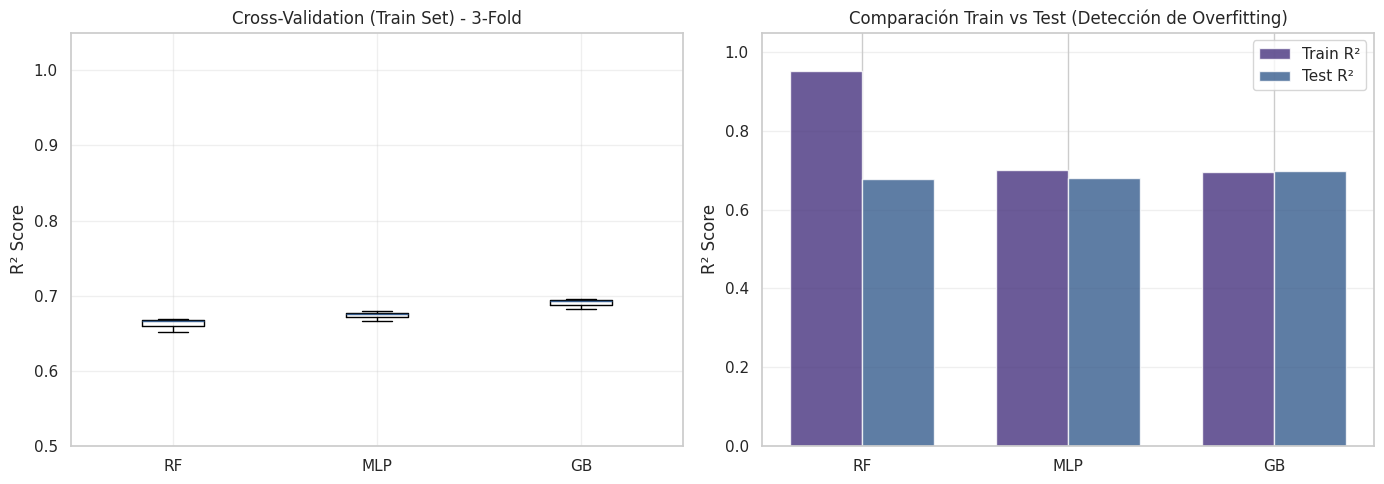


INTERPRETACIÓN: Si Train R² >> Test R², hay overfitting


In [ ]:
# Cross-validation en train set (para detectar overfitting)
kf = KFold(n_splits=3, shuffle=True, random_state=42)
cv_results = {}
test_results = {}

print("="*70)
print("EVALUACIÓN DE MODELOS: CV (Train) vs Test Set")
print("="*70)

for name, pipe in pipelines.items():
    # Cross-validation en train
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2')
    cv_results[name] = cv_scores
    
    # Entrenar en todo train set y evaluar en test
    pipe.fit(X_train, y_train)
    train_r2 = pipe.score(X_train, y_train)
    test_r2 = pipe.score(X_test, y_test)
    
    # Calcular RMSE y MAE en test
    y_pred = pipe.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mae = mean_absolute_error(y_test, y_pred)
    
    test_results[name] = {'r2': test_r2, 'rmse': test_rmse, 'mae': test_mae}
    
    print(f"\n{name}:")
    print(f"  CV Train R²:     {cv_scores.mean():.4f} ± {cv_scores.std()*2:.4f}")
    print(f"  Train R² (full): {train_r2:.4f}")
    print(f"  Test R²:         {test_r2:.4f}  {'✓ OK' if test_r2 > 0.7 else '⚠️  Bajo'}")
    print(f"  Test RMSE:       {test_rmse:.4f}")
    print(f"  Test MAE:        {test_mae:.4f}")
    print(f"  Overfitting:     {train_r2 - test_r2:.4f}  {'⚠️  Alto' if train_r2 - test_r2 > 0.1 else '✓ OK'}")

# Visualizar comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Cross-validation en train
ax1 = axes[0]
ax1.boxplot(cv_results.values(), labels=cv_results.keys())
ax1.set_ylabel('R² Score')
ax1.set_title('Cross-Validation (Train Set) - 3-Fold')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.5, 1.05])

# Gráfico 2: Train vs Test
ax2 = axes[1]
model_names = list(test_results.keys())
train_r2_vals = [pipelines[name].score(X_train, y_train) for name in model_names]
test_r2_vals = [test_results[name]['r2'] for name in model_names]

x_pos = np.arange(len(model_names))
width = 0.35
ax2.bar(x_pos - width/2, train_r2_vals, width, label='Train R²', alpha=0.8)
ax2.bar(x_pos + width/2, test_r2_vals, width, label='Test R²', alpha=0.8)
ax2.set_ylabel('R² Score')
ax2.set_title('Comparación Train vs Test (Detección de Overfitting)')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(model_names)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("INTERPRETACIÓN: Si Train R² >> Test R², hay overfitting")
print("="*70)

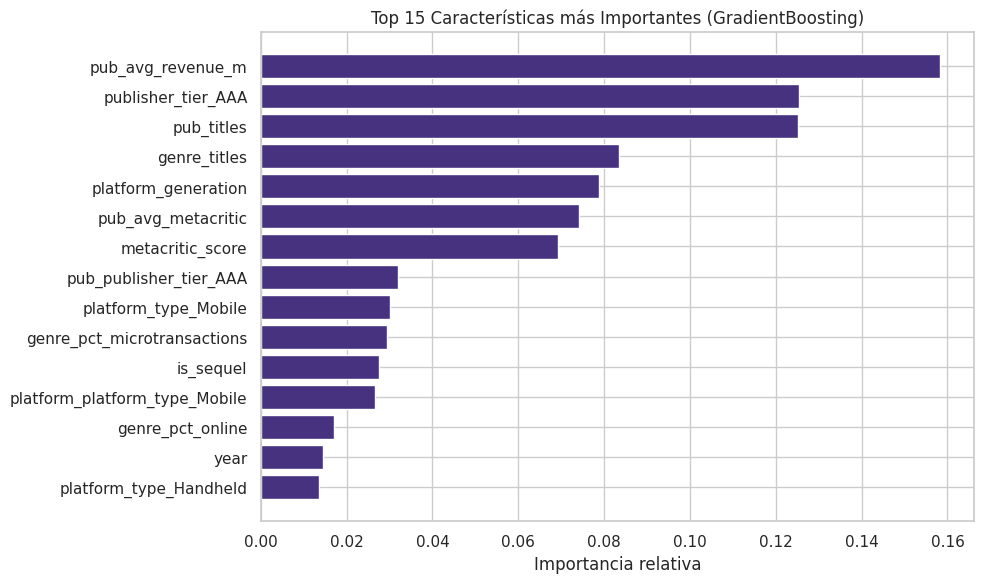

Características más importantes para predecir ventas globales:
  1. pub_avg_revenue_m (0.1583)
  2. publisher_tier_AAA (0.1255)
  3. pub_titles (0.1252)
  4. genre_titles (0.0835)
  5. platform_generation (0.0788)
  6. pub_avg_metacritic (0.0741)
  7. metacritic_score (0.0692)
  8. pub_publisher_tier_AAA (0.0319)
  9. platform_type_Mobile (0.0302)
  10. genre_pct_microtransactions (0.0294)


In [ ]:
# Importancia de características (GradientBoosting)
importancia_gb = pipelines["GB"].named_steps["model"].feature_importances_

# Obtener nombres de características transformadas
feature_names = pipelines["GB"].named_steps["preprocessor"].get_feature_names_out()
feature_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

# Top 15 más importantes
indices = np.argsort(importancia_gb)[::-1][:15]

plt.figure(figsize=(10, 6))
plt.title("Top 15 Características más Importantes (GradientBoosting)")
plt.barh(range(len(indices)), importancia_gb[indices][::-1], align="center")
plt.yticks(range(len(indices)), [feature_names[i][:40] for i in indices[::-1]])
plt.xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

print("Características más importantes para predecir ventas globales:")
for i, idx in enumerate(indices[:10]):
    print(f"  {i+1}. {feature_names[idx][:50]} ({importancia_gb[idx]:.4f})")

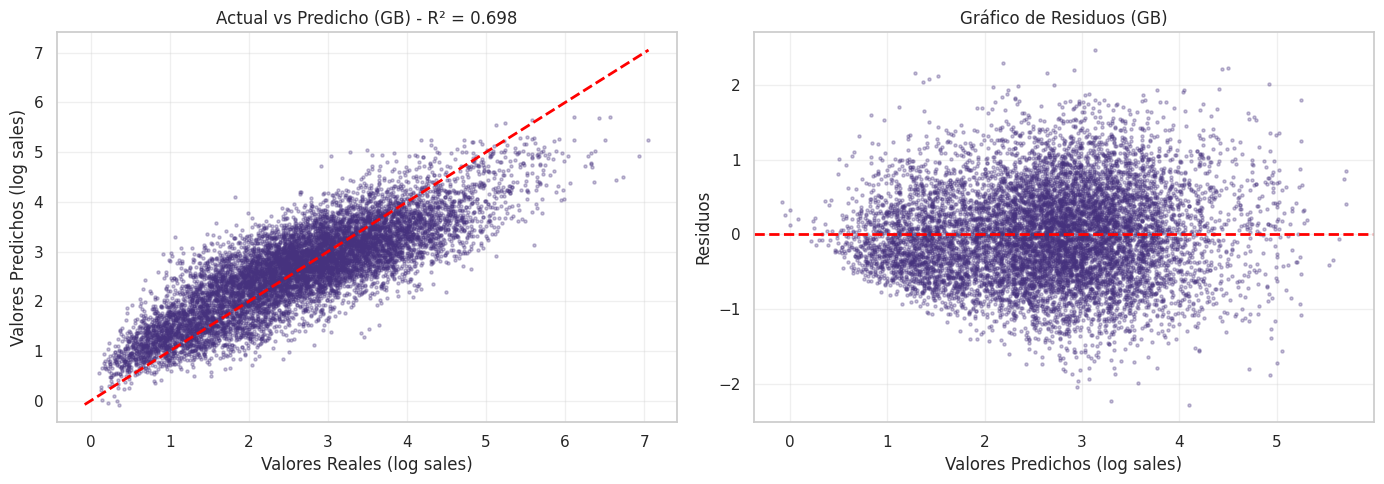

--- Análisis de errores (GB) ---
RMSE: 0.6212
MAE:  0.4957
Error promedio (sesgo): 0.0023
Desviación estándar de residuos: 0.6212
Proporción de residuos > 2*RMSE: 4.59%


In [ ]:
# Predicciones con el mejor modelo (GB)
y_pred_gb = pipelines["GB"].predict(X_test)
residuals = y_test - y_pred_gb

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicho
ax1 = axes[0]
ax1.scatter(y_test, y_pred_gb, alpha=0.3, s=5)
min_val = min(y_test.min(), y_pred_gb.min())
max_val = max(y_test.max(), y_pred_gb.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
ax1.set_xlabel("Valores Reales (log sales)")
ax1.set_ylabel("Valores Predichos (log sales)")
ax1.set_title(f"Actual vs Predicho (GB) - R² = {test_results['GB']['r2']:.3f}")
ax1.grid(True, alpha=0.3)

# Residuos
ax2 = axes[1]
ax2.scatter(y_pred_gb, residuals, alpha=0.3, s=5)
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel("Valores Predichos (log sales)")
ax2.set_ylabel("Residuos")
ax2.set_title("Gráfico de Residuos (GB)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("--- Análisis de errores (GB) ---")
print(f"RMSE: {test_results['GB']['rmse']:.4f}")
print(f"MAE:  {test_results['GB']['mae']:.4f}")
print(f"Error promedio (sesgo): {residuals.mean():.4f}")
print(f"Desviación estándar de residuos: {residuals.std():.4f}")
print(f"Proporción de residuos > 2*RMSE: {(np.abs(residuals) > 2*test_results['GB']['rmse']).mean():.2%}")

## Métricas usadas y por qué

- **R²**: Explica la proporción de la varianza de la variable objetivo que el modelo puede explicar. Es útil para comparar ajuste relativo entre modelos.
- **RMSE (Root Mean Squared Error)**: Error en las mismas unidades que la variable objetivo (aquí, log-unidades si usamos `sales_log`). Penaliza fuertemente errores grandes; útil para entender magnitud del error.
- **MAE (Mean Absolute Error)**: Error absoluto medio; robusto frente a outliers comparado con RMSE. Complementa a RMSE para una visión más estable del error típico.

Usamos los tres porque R² mide ajuste relativo, mientras que RMSE y MAE cuantifican el error en unidades interpretables y ayudan a detectar sensibilidad a outliers.

In [ ]:
# Modelos regularizados para reducir el overfitting
regularized_pipelines = {
    "RF_reg": Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=200,
            max_depth=8,
            min_samples_leaf=5,
            max_features='sqrt',
            random_state=42
        ))
    ]),
    "GB_reg": Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            random_state=42
        ))
    ]),
    "MLP_reg": Pipeline([
        ('preprocessor', preprocessor),
        ('model', MLPRegressor(
            hidden_layer_sizes=(100, 50),
            alpha=0.001,
            early_stopping=True,
            max_iter=1000,
            random_state=42
        ))
    ])
}

results_reg = {}

print("Evaluando modelos regularizados sobre el conjunto de test:\n")
for name, pipe in regularized_pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    train_r2 = pipe.score(X_train, y_train)
    test_r2 = pipe.score(X_test, y_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    results_reg[name] = {
        'train_r2': train_r2,
        'test_r2': test_r2,
        'rmse': rmse,
        'mae': mae
    }
    print(f"{name}: \n  Train R² = {train_r2:.4f}\n  Test R² = {test_r2:.4f}\n  RMSE = {rmse:.4f}\n  MAE = {mae:.4f}\n  Brecha = {train_r2 - test_r2:.4f}")

print("\nResumen comparativo:")
for name, metrics in results_reg.items():
    print(f"- {name}: test R²={metrics['test_r2']:.4f}, RMSE={metrics['rmse']:.4f}, MAE={metrics['mae']:.4f}")

# Visualización de la comparación Train vs Test para modelos regularizados
fig, ax = plt.subplots(figsize=(10, 5))
bar_labels = list(results_reg.keys())
train_vals = [results_reg[n]['train_r2'] for n in bar_labels]
test_vals = [results_reg[n]['test_r2'] for n in bar_labels]
x = np.arange(len(bar_labels))
width = 0.35
ax.bar(x - width/2, train_vals, width, label='Train R²', alpha=0.8)
ax.bar(x + width/2, test_vals, width, label='Test R²', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(bar_labels)
ax.set_ylabel('R²')
ax.set_title('Train vs Test R² para modelos regularizados')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()